In [1]:
import tensorflow as tf

2026-05-18 17:00:14.768780: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-18 17:00:15.097155: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-18 17:00:16.140422: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [3]:
import os, shutil, pathlib

In [4]:
import random

In [ ]:
categories=["benign","malignant","normal"]
splits={'train':0.7,'validation':0.2,'test':0.1}

random.seed(1337)
for cat in categories:
    source_cat_dir=base_dir / cat
    all_files=os.listdir(source_cat_dir)
    images=[f for f in all_files if "mask" not in f and f.endswith('.png')]

    random.shuffle(images)

    n=len(images)
    idx_val=int(n*splits['train'])
    idx_test=int(n*(splits['train']+splits['validation']))

    data_split={ 
        'train': images[:idx_val],
        'validation': images[idx_val:idx_test],
        'test': imror occurred while processing the message. Please try again.
In caages[idx_test:]
    }
    for phase, file_list in data_split.items():
        input_path=output_dir / phase / 'inputs' / cat
        target_path= output_dir / phase / 'targets' / cat

        os.makedirs(input_path, exist_ok=True)
        os.makedirs(target_path, exist_ok=True)

        for fname in file_list: 
            shutil.copyfile(src=source_cat_dir / fname, dst=input_path / fname)
            mask_name=fname.replace(".png", "_mask.png")
            if os.path.exists(source_cat_dir / mask_name):
                shutil.copyfile(src=source_cat_dir / mask_name, dst=target_path / mask_name)
            else:
                Print(f"Mask Missing for {fname}")


In [5]:
base_dir=pathlib.Path("archive/Dataset_BUSI_with_GT") 
output_dir=pathlib.Path("archive/BUSI_Splitted")

In [6]:
base_path = pathlib.Path("archive/BUSI_Splitted")
input_img_paths = sorted([str(p) for p in (base_path).rglob("inputs/*/*.png")])
target_paths = sorted([str(p) for p in (base_path).rglob("targets/*/*.png")])
print(f"Total images trouvées : {len(input_img_paths)}")
print(f"Total masques trouvés : {len(target_paths)}")

Total images trouvées : 780
Total masques trouvés : 780


In [7]:
base_path = pathlib.Path("archive/BUSI_Splitted")
input_img_paths = sorted([str(p) for p in (base_path).rglob("inputs/*/*.png")])
target_paths = sorted([str(p) for p in (base_path).rglob("targets/*/*.png")])
print(f"Total images trouvées : {len(input_img_paths)}")
print(f"Total masques trouvés : {len(target_paths)}")

Total images trouvées : 780
Total masques trouvés : 780


In [8]:
from tensorflow.keras.utils import load_img,img_to_array
img_size=(256,256)
num_imgs=len(input_img_paths)
random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_paths)

def path_to_input_image(path):
    return img_to_array(load_img(path, target_size=img_size))
def path_to_target(path):
    img = img_to_array(
        load_img(path, target_size=img_size, color_mode="grayscale"))
    img=(img>127).astype("uint8")
    return img 

input_imgs=np.zeros((num_imgs,)+img_size+(3,),dtype="float32")
targets=np.zeros((num_imgs,)+img_size+(1,), dtype="uint8")
for i in range(num_imgs):
    input_imgs[i]=path_to_input_image(input_img_paths[i])
    targets[i]=path_to_target(target_paths[i])
num_val_samples=200
train_input_imgs=input_imgs[:-num_val_samples]
train_targets=targets[:-num_val_samples]
val_input_imgs=input_imgs[-num_val_samples:]
val_targets=targets[-num_val_samples:]

In [9]:
from tensorflow.keras.applications.vgg19 import preprocess_input

def simple_augment(image, mask):
    seed = tf.random.uniform([2], maxval=10000, dtype=tf.int32)
    
    image = tf.image.stateless_random_flip_left_right(image, seed=seed)
    mask = tf.image.stateless_random_flip_left_right(mask, seed=seed)

    angles = tf.random.stateless_uniform([], seed=seed, minval=-0.2, maxval=0.2)
    image = tf.image.rot90(image, k=tf.cast(tf.random.stateless_uniform([], seed=seed, minval=0, maxval=4, dtype=tf.int32), tf.int32))
    mask = tf.image.rot90(mask, k=tf.cast(tf.random.stateless_uniform([], seed=seed, minval=0, maxval=4, dtype=tf.int32), tf.int32))

    image = tf.image.stateless_random_brightness(image, max_delta=0.05, seed=seed)
    image = tf.image.stateless_random_contrast(image, lower=0.95, upper=1.05, seed=seed)

    do_sobel = tf.random.stateless_uniform([], seed=seed, minval=0, maxval=1)
    if do_sobel > 0.7:
        image_gray = tf.image.rgb_to_grayscale(image)
        sobel = tf.image.sobel_edges(tf.expand_dims(image_gray, 0))
        sobel_mag = tf.sqrt(tf.reduce_sum(tf.square(sobel), axis=-1))
        sobel_mag = tf.squeeze(sobel_mag, axis=0) 
        sobel_mag = (sobel_mag / (tf.reduce_max(sobel_mag) + 1e-7)) * 255.0
        image = tf.concat([sobel_mag, sobel_mag, sobel_mag], axis=-1)

    
    
    image = tf.keras.applications.vgg19.preprocess_input(image)
    mask = tf.cast(mask, tf.float32) 
    return image, mask

def simple_preprocess_val(image, mask):
    image = preprocess_input(image)
    mask = tf.cast(mask, tf.float32)
    return image, mask

In [10]:
train_ds = tf.data.Dataset.from_tensor_slices((train_input_imgs, train_targets))
val_ds = tf.data.Dataset.from_tensor_slices((val_input_imgs, val_targets))

train_ds = (train_ds
            .shuffle(len(train_input_imgs))
            .map(simple_augment, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(8) 
            .prefetch(tf.data.AUTOTUNE))

val_ds = (val_ds
          .map(simple_preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(8)
          .prefetch(tf.data.AUTOTUNE))

I0000 00:00:1779120039.383094   46504 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6154 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [11]:
from tensorflow.keras import backend as K
def dice_coef(y_true,y_pred,smooth=1e-6):
    # we flat out tensor
    y_true_f=K.flatten(K.cast(y_true,'float32'))
    y_pred_f=K.flatten(y_pred)

    #calculate intersection
    intersection=K.sum(y_true_f*y_pred_f)
    return (2.*intersection+smooth) / (K.sum(y_true_f)+K.sum(y_pred_f)+smooth)
def dice_loss(y_true,y_pred):
    return 1-dice_coef(y_true,y_pred)

In [12]:
def specificity(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')
    true_negatives = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    possible_negatives = K.sum(K.round(K.clip(1 - y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())

def f1_score(y_true, y_pred):
    p = keras.metrics.Precision()(y_true, y_pred)
    r = keras.metrics.Recall()(y_true, y_pred)
    return 2 * ((p * r) / (p + r + K.epsilon()))

In [13]:
def channel_attention_module(x, ratio=8):
    channels=x.shape[-1]
    shared_layer_one=keras.layers.Dense(channels // ratio, activation="relu", use_bias=False)
    shared_layer_two=keras.layers.Dense(channels, use_bias=False)

    # avgpool 
    avg_pool=keras.layers.GlobalAveragePooling2D()(x)
    avg_pool=keras.layers.Reshape((1,1,channels))(avg_pool)
    avg_out=shared_layer_two(shared_layer_one(avg_pool))

    max_pool=keras.layers.GlobalMaxPooling2D()(x)
    max_pool=keras.layers.Reshape((1,1,channels))(max_pool)
    max_out=shared_layer_two(shared_layer_one(max_pool))

    cbam_feature=keras.layers.Add()([avg_out,max_out])
    cbam_feature=keras.layers.Activation('sigmoid')(cbam_feature)

    return keras.layers.multiply([x,cbam_feature])

In [14]:
from keras import ops
def spatial_attention_module(x):
    #
    avg_pool = ops.mean(x,axis=-1,keepdims=True)
    max_pool= ops.max(x,axis=-1,keepdims=True)

    #concatenation
    concat=keras.layers.Concatenate(axis=-1)([avg_pool, max_pool])

    #7x7 filter and sigmoid
    cbam_feature=keras.layers.Conv2D(
        filters=1, kernel_size=7, strides=1,
        padding="same", activation="sigmoid", use_bias=False
    )(concat)

    #muliply and return
    return keras.layers.multiply([x,cbam_feature])

In [15]:
def cbam_block(x,ratio=8):
    x=channel_attention_module(x,ratio)
    x=spatial_attention_module(x)
    return x

In [16]:
model = keras.models.load_model("BUSI_VGG19_trams_Unet.keras")

TypeError: Could not locate function 'dice_loss'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'dice_loss', 'registered_name': 'function'}

In [21]:
model = keras.models.load_model(
    "BUSI_VGG19_trams_Unet.keras", 
    custom_objects={
        "dice_coef": dice_coef,
        "dice_loss": dice_loss,
        "log_cosh_dice_loss": log_cosh_dice_loss,
        "cbam_block": cbam_block 
    }
)

TypeError: Could not locate function 'specificity'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'specificity', 'registered_name': 'function'}

In [16]:
def total_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dl = dice_loss(y_true, y_pred)
    return bce + dl

In [17]:
def hybrid_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    return (0.95 * dice_loss(y_true, y_pred)) + (0.05 * tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred)))

In [18]:
def log_cosh_dice_loss(y_true, y_pred):
    x = dice_loss(y_true, y_pred)
    return tf.math.log(tf.math.cosh(x))

In [19]:
custom_dict = {
    "dice_loss": dice_loss,
    "dice_coef": dice_coef,
    "specificity": specificity
}

In [29]:
model = keras.models.load_model("BUSI_VGG19_trams_Unet.keras", custom_objects=custom_dict, compile=False)

In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=log_cosh_dice_loss,
    metrics=["accuracy", 
             keras.metrics.Precision(name='precision'), 
             keras.metrics.Recall(name='recall'), 
             specificity, 
             dice_coef]
)

In [25]:
callbacks=[
    keras.callbacks.ModelCheckpoint("BUSI_VGG19_trams_Unet_data_aug.keras",
                                    save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_dice_coef", mode="max", 
                                  patience=10, restore_best_weights=True),
    
    keras.callbacks.ReduceLROnPlateau(
        factor=0.2, patience=5, monitor="val_loss")
]
history=model.fit(train_ds, 
                  validation_data=val_ds,
                  epochs=50,
                  callbacks=callbacks)

Epoch 1/50


2026-04-20 17:10:58.080458: E tensorflow/core/util/util.cc:131] oneDNN supports DT_UINT8 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-04-20 17:10:59.902354: I external/local_xla/xla/service/service.cc:163] XLA service 0x75ed34009ad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-20 17:10:59.902406: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-20 17:10:59.999862: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-20 17:11:00.522023: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-04-20 17:11:01.184346: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local 

 2/73 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.9769 - dice_coef: 0.7409 - loss: 0.0376 - precision: 0.7793 - recall: 0.7142 - specificity: 0.9908  

I0000 00:00:1776701474.650831   17892 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9359 - dice_coef: 0.5389 - loss: 0.1141 - precision: 0.6153 - recall: 0.4884 - specificity: 0.9737

2026-04-20 17:11:21.409717: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_10', 236 bytes spill stores, 236 bytes spill loads

2026-04-20 17:11:22.265922: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 8.33GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-20 17:11:22.573665: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-20 17:11:22.717262: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please invest

73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 294ms/step - accuracy: 0.9354 - dice_coef: 0.5412 - loss: 0.1119 - precision: 0.5898 - recall: 0.5243 - specificity: 0.9697 - val_accuracy: 0.9548 - val_dice_coef: 0.6679 - val_loss: 0.0588 - val_precision: 0.7709 - val_recall: 0.5976 - val_specificity: 0.9849 - learning_rate: 1.0000e-04
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.9330 - dice_coef: 0.5759 - loss: 0.0991 - precision: 0.5619 - recall: 0.5852 - specificity: 0.9618 - val_accuracy: 0.9460 - val_dice_coef: 0.6569 - val_loss: 0.0603 - val_precision: 0.6451 - val_recall: 0.6821 - val_specificity: 0.9682 - learning_rate: 1.0000e-04
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.9398 - dice_coef: 0.5604 - loss: 0.1041 - precision: 0.6288 - recall: 0.5295 - specificity: 0.9741 - val_accuracy: 0.9244 - val_dice_coef: 0.6004 - val_loss: 0.0804 - val_precision: 0.5099 - val_recall: 0.7626 - val_specificity: 0.9379 - learning_rate: 1.0000e-04
Epoch 4/50
73/73 ━━━━━

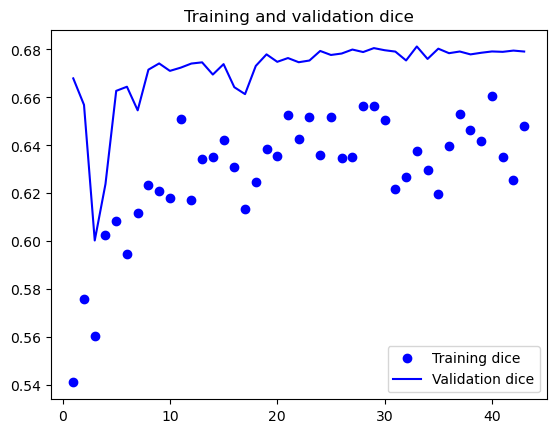

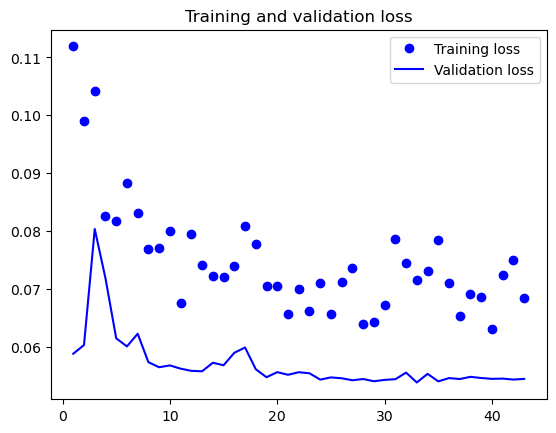

In [26]:
dice = history.history["dice_coef"]
val_dice = history.history["val_dice_coef"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(dice) + 1)
plt.plot(epochs, dice, "bo", label="Training dice")
plt.plot(epochs, val_dice, "b", label="Validation dice")
plt.title("Training and validation dice")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [27]:
model.load_weights("BUSI_VGG19_trams_Unet_data_aug.keras")
for layer in model.layers:
    if "block5" in layer.name or "block4" in layer.name:
        layer.trainable = True
    else:
        
        if "block" in layer.name:
            layer.trainable = False
        else:
            layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=log_cosh_dice_loss,
    metrics=["accuracy", 
             keras.metrics.Precision(name='precision'), 
             keras.metrics.Recall(name='recall'), 
             specificity, 
             dice_coef]
)

In [28]:
callbacks=[
    keras.callbacks.ModelCheckpoint("BUSI_VGG19_trams_Unet_data_aug_FT.keras",
                                    save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_dice_coef", mode="max", 
                                  patience=10, restore_best_weights=True),
    
    keras.callbacks.ReduceLROnPlateau(
        factor=0.2, patience=5, monitor="val_loss")
]
history=model.fit(train_ds, 
                  validation_data=val_ds,
                  epochs=50,
                  callbacks=callbacks)

Epoch 1/50


2026-04-20 17:22:40.035779: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 8.40GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-20 17:22:41.183998: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 8.28GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9453 - dice_coef: 0.6139 - loss: 0.0808 - precision: 0.6455 - recall: 0.6023 - specificity: 0.9728

2026-04-20 17:22:54.470130: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 4 bytes spill stores, 4 bytes spill loads

2026-04-20 17:22:54.588255: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.18GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-20 17:22:54.734643: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 8.34GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


73/73 ━━━━━━━━━━━━━━━━━━━━ 26s 244ms/step - accuracy: 0.9413 - dice_coef: 0.5997 - loss: 0.0867 - precision: 0.6250 - recall: 0.5930 - specificity: 0.9699 - val_accuracy: 0.9500 - val_dice_coef: 0.6714 - val_loss: 0.0560 - val_precision: 0.6779 - val_recall: 0.6825 - val_specificity: 0.9725 - learning_rate: 1.0000e-05
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 151ms/step - accuracy: 0.9463 - dice_coef: 0.6255 - loss: 0.0796 - precision: 0.6566 - recall: 0.6318 - specificity: 0.9725 - val_accuracy: 0.9559 - val_dice_coef: 0.6830 - val_loss: 0.0528 - val_precision: 0.7583 - val_recall: 0.6367 - val_specificity: 0.9828 - learning_rate: 1.0000e-05
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - accuracy: 0.9481 - dice_coef: 0.6371 - loss: 0.0725 - precision: 0.6743 - recall: 0.6304 - specificity: 0.9747 - val_accuracy: 0.9594 - val_dice_coef: 0.6804 - val_loss: 0.0552 - val_precision: 0.8501 - val_recall: 0.5811 - val_specificity: 0.9913 - learning_rate: 1.0000e-05
Epoch 4/50
73/73 ━

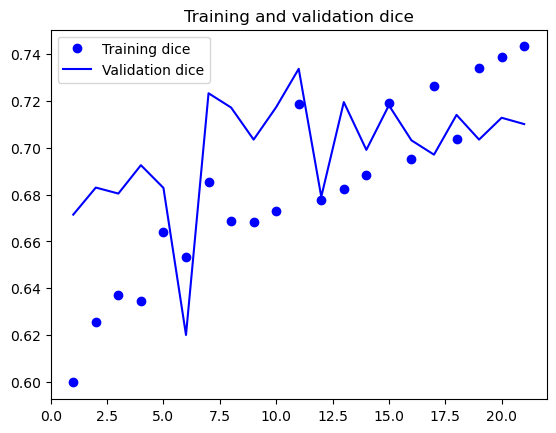

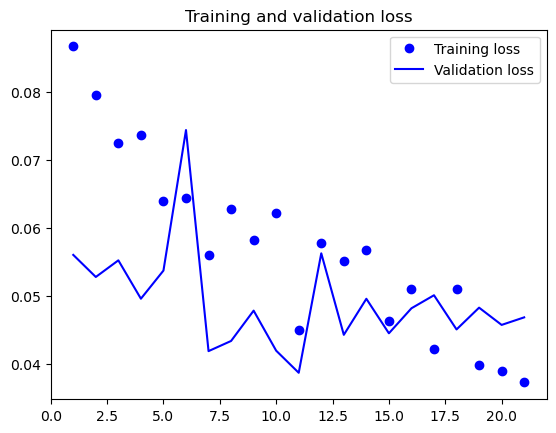

In [29]:
dice = history.history["dice_coef"]
val_dice = history.history["val_dice_coef"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(dice) + 1)
plt.plot(epochs, dice, "bo", label="Training dice")
plt.plot(epochs, val_dice, "b", label="Validation dice")
plt.title("Training and validation dice")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [30]:
model.evaluate(val_ds)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9612 - dice_coef: 0.7337 - loss: 0.0387 - precision: 0.7720 - recall: 0.7117 - specificity: 0.9822


[0.038653865456581116,
 0.9611655473709106,
 0.7719767093658447,
 0.7117357850074768,
 0.9821625351905823,
 0.7337461709976196]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step


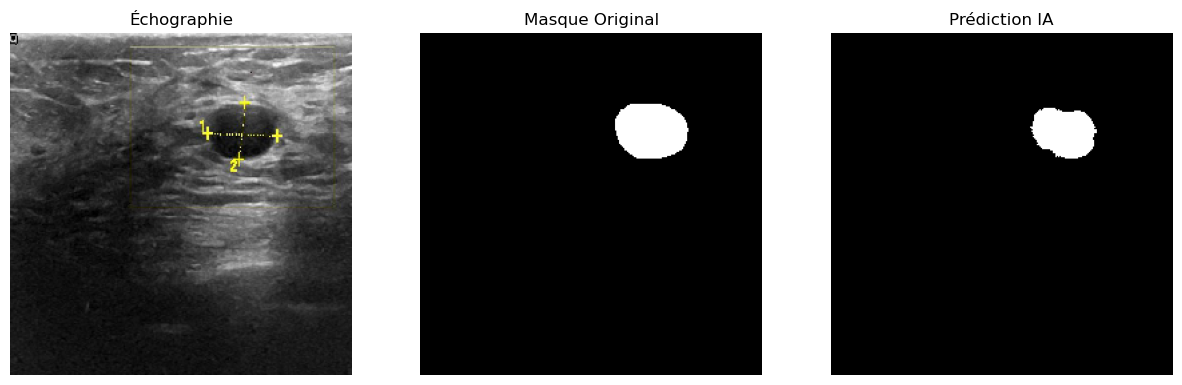

In [23]:
model= keras.models.load_model("/home/bigbro/Bureau/Projet_PFE_models/BUSI_VGG19_trams_Unet_data_aug_FT.keras", custom_objects=custom_dict, compile=False)
from tensorflow.keras.utils import array_to_img
i = 10
test_image = val_input_imgs[i]
true_mask = val_targets[i] 


pred = model.predict(np.expand_dims(test_image, 0))[0]
pred_mask = (pred > 0.5).astype("uint8")


plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
plt.title("Échographie")
plt.axis("off")
plt.imshow(array_to_img(test_image))


plt.subplot(1, 3, 2)
plt.title("Masque Original")
plt.axis("off")
plt.imshow(true_mask.squeeze(), cmap="gray")


plt.subplot(1, 3, 3)
plt.title("Prédiction IA")
plt.axis("off")
plt.imshow(pred_mask.squeeze() * 255, cmap="gray")

plt.show()